# Análise comparativa de modelos

A base de dados contém informações detalhadas sobre diamantes, incluindo variáveis como preço, peso (`carat`), qualidade do corte, cor, e claridade. Ao todo, são 53.940 registros e 10 variáveis, que variam entre dados quantitativos e qualitativos. Esta base oferece uma oportunidade rica para entender como diferentes atributos influenciam o preço de um diamante, permitindo comparações entre diferentes grupos e categorias.

## Metodologia

- **Padronização de variáveis**:  As variáveis quantitativas (ex.: `price`, `carat`, `x`, `y`, `z`, `depth`, `table`) serão padronizadas para ter média 0 e desvio padrão 1. Isso garante que todas as variáveis sejam comparáveis em termos de escala e que a análise não seja dominada por variáveis com grandes magnitudes.

- **Preparação dos dados**: 
  - Tratamento de Valores Faltantes: Verificação e tratamento de valores ausentes, se necessário.
  - Transformação de Variáveis Categóricas: Variáveis como `cut`, `color`, e `clarity` serão transformadas em variáveis dummy ou codificadas, se necessário, para facilitar a análise comparativa.
  
---

In [1]:
from IPython.display import display, Markdown
import joblib
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression, BayesianRidge
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import ShuffleSplit, GridSearchCV, KFold, cross_validate
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer

## 1. Obtenção de dados

In [2]:
df = pd.read_csv("../data/raw/data.csv")
df_dict = pd.read_csv("../data/external/dictionary.csv")
df_dict

,variavel,descricao,tipo,subtipo
0,carat,Peso do diamante (0.2--5.01),quantitativa,contínua
1,cut,"Qualidade do corte (Fair, Good, Very Good, Pre...",qualitativa,ordinal
2,color,"Cor do diamante, de D (melhor) a J (pior)",qualitativa,ordinal
3,clarity,"Medida de quão claro é o diamante (I1 (pior), ...",qualitativa,ordinal
4,depth,Percentual de profundidade total = z / média(x...,quantitativa,contínua
5,table,Largura do topo do diamante em relação ao pont...,quantitativa,contínua
6,price,"Preço em dólares americanos (US$326--US$18,823)",quantitativa,contínua
7,x,Comprimento em mm (0--10.74),quantitativa,contínua
8,y,Largura em mm (0--58.9),quantitativa,contínua
9,z,Profundidade em mm (0--31.8),quantitativa,contínua


In [3]:
print('informações do Dataframe:')
df.info()

informações do Dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


As variáveis do conjunto de dados estão distribuídas da seguinte forma:
- **float**: 6 (`carat`, `depth`, `table`, `x`, `y` e `z`)
- **object**: 3 (`cut`, `color` e `clarity`), todas são Strings
- **int**: 1 (`price`)

In [4]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

Nenhuma das colunas apresenta dados faltantes.

carat: Detectadas 1889 outliers.
depth: Detectadas 2545 outliers.
table: Detectadas 605 outliers.
price: Detectadas 3540 outliers.
x: Detectadas 32 outliers.
y: Detectadas 29 outliers.
z: Detectadas 49 outliers.


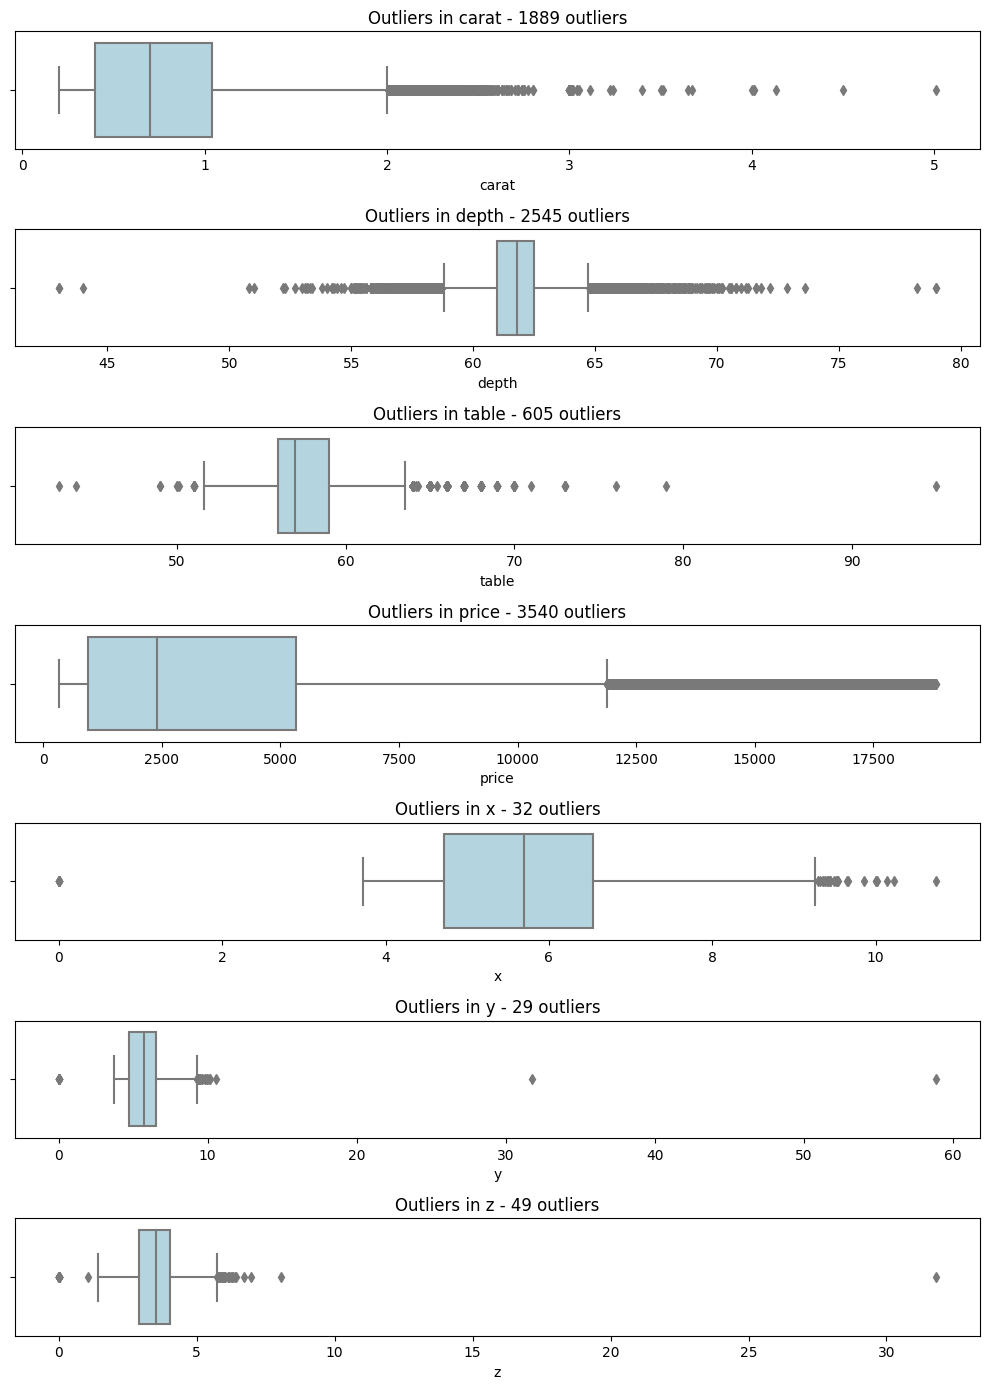

In [5]:
def detect_outliers_iqr(df):
    outliers_dict = {}
    for column in df.select_dtypes(include=[np.number]).columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]
        outliers_dict[column] = outliers
        
    return outliers_dict

def visualize_outliers(outliers_dict, df):
    numeric_columns = df.select_dtypes(include=[np.number]).columns
    num_columns = len(numeric_columns)

    plt.figure(figsize=(10, num_columns * 2))
    
    for i, column in enumerate(numeric_columns, 1):
        plt.subplot(num_columns, 1, i)
        sns.boxplot(x=df[column], color='lightBlue')
        plt.title(f'Outliers in {column} - {len(outliers_dict[column])} outliers')
    
    plt.tight_layout()
    plt.show()

outliers_dict = detect_outliers_iqr(df)

for column, outliers_data in outliers_dict.items():
    print(f"{column}: Detectadas {len(outliers_data)} outliers.")

visualize_outliers(outliers_dict, df)

- É perceptível um número elevado de Outliers em todas as colunas, porém o que mais chama atenção são os valores 0 para as colunas relacionadas às dimensões físicas dos diamantes (`x`, `y`, `z`) claramente devido a valores faltantes.
- Em certos contextos, outliers podem ter significados importantes e devem ser mantidos.

In [6]:
df = df.drop(df[df["x"]==0].index)
df = df.drop(df[df["y"]==0].index)
df = df.drop(df[df["z"]==0].index)
df.shape

(53920, 10)

 - Após a exclusão das linhas que apresentavam valores 0 nas variáveis `x`, `y` e `z` perdemos 19 registros.
 - Como temos uma base de dados com muitos registros, podemos excluir Outliers presentes nas colunas quantitativas.

In [7]:
def remove_outliers_zscore(df, columns, threshold=3):
    for col in columns:
        z_scores = stats.zscore(df[col])
        df = df[(z_scores < threshold) & (z_scores > -threshold)]
    return df

columns_to_filter = ["depth", "table", "x", "y", "z"]
df = remove_outliers_zscore(df, columns_to_filter)
df.shape

(52925, 10)

- com a exclusão de Outliers, perdemos 995 registros.
---

## 2. Preparação de dados

Aqui realizamos a normalização, codificação e o tratamento de dados discrepantes e/ou faltantes dentro do conjunto de dados.

### 2.1 Preparação de variáveis

In [8]:
target_column = 'price'

ordinal_columns = (
    df_dict
    .query("subtipo == 'ordinal'")
    .variavel
    .to_list()
)
continuous_columns = (
    df_dict
    .query("subtipo == 'contínua' and variavel != @target_column")
    .variavel
    .to_list()
)

display(Markdown(
    f"- **Variável alvo:** {target_column} \n\n"
    f"- **Variáveis qualitativas ordinais:** {ordinal_columns} \n"
    f"- **Variáveis quantitativas contínuas:** {continuous_columns} \n"
))
    
X = df.drop(columns=[target_column], axis=1)
y = df[target_column]

- **Variável alvo:** price 

- **Variáveis qualitativas ordinais:** ['cut', 'color', 'clarity'] 
- **Variáveis quantitativas contínuas:** ['carat', 'depth', 'table', 'x', 'y', 'z'] 


### 2.2 Pipeline de dados

In [9]:
class LabelEncoderPipelineFriendly(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.label_encoders = {}

    def fit(self, X, y=None):
        for col in X.columns:
            le = LabelEncoder()
            le.fit(X[col])
            self.label_encoders[col] = le
        return self

    def transform(self, X):
        X_transformed = X.copy()
        for col, le in self.label_encoders.items():
            X_transformed[col] = le.transform(X[col])
        return X_transformed

ordinal_preprocessor = Pipeline([
    ('label_encoding', LabelEncoderPipelineFriendly()),
    ('normalization', StandardScaler())
])
continuous_preprocessor = Pipeline([
    ('missing', SimpleImputer(strategy='median')),
    ('normalization', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('nominal', ordinal_preprocessor, ordinal_columns),
    ('continuous', continuous_preprocessor, continuous_columns)
])

---

## 3. Seleção de Modelos

Vamos analisar quatro modelos de regressão, que serão testados utilizando os seguintes métodos de validação:
- K-Nearest Neighbors (KNN)
- Decision Tree
- Random Forest
- Bayesian Ridge Regression

Cada um desses algoritmos será testado com diferentes hiperparâmetros para identificar o melhor modelo e a melhor configuração possível.

Utilizaremos as seguintes métricas para análise:

- MAE (Mean Absolute Error): Erro absoluto médio, que mede a média das diferenças absolutas entre as previsões e os valores reais.
- MSE (Mean Squared Error): Erro quadrático médio, que mede a média dos quadrados das diferenças entre as previsões e os valores reais.
- R² (Coeficiente de Determinação): Mede a proporção da variância dos dados que é explicada pelo modelo.

In [10]:
# experiment settings
n_splits_comparative_analysis = 10
n_folds_grid_search = 5
test_size = .2
random_state = 42
scoring = make_scorer(r2_score)
metrics = {
    'MAE': make_scorer(mean_absolute_error),
    'MSE': make_scorer(mean_squared_error),
    'R2': make_scorer(r2_score)
}

# model settings
max_iter = 1000
models = [
    ('K-Nearest Neighbors', KNeighborsRegressor(), {
        "n_neighbors": range(3, 20, 2), 
        'weights': ['uniform', 'distance']}),
    
    ('Decision Tree',  DecisionTreeRegressor(random_state=random_state), {
        'criterion':['squared_error','friedman_mse'],
        'max_depth': [3, 6, 8]}),
    
    ('Random Forest',  RandomForestRegressor(random_state=random_state), {
        'criterion':['squared_error','friedman_mse'],
        'max_depth': [3, 6, 8], 
        'n_estimators': [10, 30]}),
    
    ('Bayesian Ridge Regression', BayesianRidge(), {
        'alpha_1': [1e-6, 1e-5, 1e-4],
        'alpha_2': [1e-6, 1e-5, 1e-4],
        'lambda_1': [1e-6, 1e-5, 1e-4],
        'lambda_2': [1e-6, 1e-5, 1e-4]})
]

In [11]:
start_time = time.time()
total_models = len(models)

results = pd.DataFrame({})
cross_validate_grid_search = KFold(n_splits=n_folds_grid_search)
cross_validate_comparative_analysis = ShuffleSplit(n_splits=n_splits_comparative_analysis, test_size=test_size, random_state=random_state)
for model_name, model_object, model_parameters in models:
    print(f"running {model_name}...")
    model_grid_search = GridSearchCV(
        estimator=model_object,
        param_grid=model_parameters,
        scoring=scoring,
        n_jobs=-1,
        cv=cross_validate_grid_search
    )
    approach = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model_grid_search)
    ])
    scores = cross_validate(
        estimator=approach,
        X=X,
        y=y,
        cv=cross_validate_comparative_analysis,
        n_jobs=-1,
        scoring=metrics
    )
    scores_df = pd.DataFrame(scores)
    scores_df['model_name'] = model_name
    results = pd.concat([results, scores_df], ignore_index=True)
    numeric_scores_df = scores_df.select_dtypes(include=['float64', 'int64'])
    scores_aggregated = numeric_scores_df.agg(['mean', 'std'])
    display(scores_aggregated)

running K-Nearest Neighbors...


,fit_time,score_time,test_MAE,test_MSE,test_R2
mean,168.685198,1.799595,377.575836,575725.162369,0.963479
std,41.464277,0.441083,4.759422,15230.625234,0.000981


running Decision Tree...


,fit_time,score_time,test_MAE,test_MSE,test_R2
mean,5.243504,0.039473,390.734300,509272.462969,0.967706
std,1.160297,0.010477,7.532966,25940.642699,0.001383


running Random Forest...


,fit_time,score_time,test_MAE,test_MSE,test_R2
mean,159.405831,0.110675,352.774006,417952.794913,0.973491
std,38.399108,0.062075,6.392804,19909.796510,0.001176


running Bayesian Ridge Regression...


,fit_time,score_time,test_MAE,test_MSE,test_R2
mean,24.326558,0.058117,821.608817,1.631037e+06,0.896542
std,3.765492,0.025388,10.385937,5.704485e+04,0.003474


In [12]:
def highlight_best(s, props=''):
    if s.name[1] != 'std':
        if s.name[0].endswith('time'):
            return np.where(s == np.nanmin(s.values), props, '')
        return np.where(s == np.nanmax(s.values), props, '')

display(Markdown("### 3.1 Resultados gerais"))
(
    results
    .groupby('model_name')
    .agg(['mean', 'std']).T
    .style
    .apply(highlight_best, props='color:white;background-color:gray;font-weight: bold;', axis=1)
    .set_table_styles([{'selector': 'td', 'props': 'text-align: center;'}])
)

### 3.1 Resultados gerais

**Tempo de ajuste(fit_time):***
- Bayesian Ridge Regression é o mais rápido (24,33 segundos em média).
- KNN e Random Forest são os mais lentos (168,69 e 159,41 segundos em média, respectivamente).

**Tempo de Pontuação (score_time):**
- Decision Tree e Bayesian Ridge Regression têm tempos de pontuação muito baixos (0,039 e 0,058 segundos, respectivamente).
- K-Nearest Neighbors é o mais lento (1,8 segundos).

**Erro Absoluto Médio (MAE):**
- Random Forest tem o menor MAE (352,77), indicando previsões mais próximas dos valores reais.
- Bayesian Ridge Regression tem o maior MAE (821,61), o que sugere que suas previsões estão menos precisas.

**Erro Quadrático Médio (MSE):**
- Random Forest também apresenta o menor MSE (417.952), novamente sugerindo melhor desempenho.
- Bayesian Ridge Regression tem o maior MSE (1.631.037), o que penaliza ainda mais seus erros de previsão.

**Coeficiente de Determinação (R²):**
- Random Forest tem o maior R² (0,973), indicando que ele explica a maior parte da variância nos dados.
- Bayesian Ridge Regression tem o menor R² (0,897), o que reflete sua menor precisão preditiva.

Random Forest foi o melhor modelo em termos de precisão, com o menor MAE e MSE, além do maior R². Decision Tree e K-Nearest Neighbors apresentaram resultados decentes, mas com um equilíbrio entre tempo de execução e precisão.

### 3.2 Persistência do Modelo

In [14]:
#Obtem o modelo e os parametros ganhadores
model_name, model_object, model_parameters  = [foo for foo in models if foo[0] == "Random Forest"][0] 


model_grid_search = GridSearchCV(
        estimator=model_object,
        param_grid=model_parameters,
        scoring=scoring,
        n_jobs=-1,
        cv=cross_validate_grid_search
    )

approach = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model_grid_search)
])

approach.fit(X, y) #Seleciona o approach

print(f"Hiper parâmetros do modelo: {approach.steps[1][1].best_params_}")

Hiper parâmetros do modelo: {'criterion': 'squared_error', 'max_depth': 8, 'n_estimators': 30}


In [15]:
joblib.dump(approach, '../models/model.joblib')

['../models/model.joblib']